# Problem Setup (Solving Poisson equation 1D)

**PDE:**

$$\frac{\partial^2 y}{\partial x^2} + \pi^2 sin(\pi x) = 0,x\in[-1,1]$$

**Loss Residual:**
Andaikan $y_{nn}$ merupakan fungsi neural networks. Sehingga residualnya
$$\frac{\partial^2 y_{nn}}{\partial x^2}+ \pi^2 sin(\pi x) \approx \frac{\partial^2 y}{\partial x^2} + \pi^2 sin(\pi x) \approx 0$$

Karena memakai hard constraint dengan $p(x)=x(1-x)$,maka kita tidak memerlukan loss dari bc. Sehingga total dari loss:
$$Loss = Loss_{pde}$$

# Boundary Conditions
$$y(-1) = 0, y(1) = 0$$

# Analytic Solution
$$y(x) = sin(x)$$

In [1]:
import torch
import torch.autograd as autograd   # computation graph
from torch import Tensor # tensor node in the computation graph
import torch.nn as nn # neural network from torch
import torch.optim as optim # optimizers e.g. gradient descent, ADAM, etc.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker
from sklearn.model_selection import train_test_split

import numpy as np
import time
# from pyDOE import lhs # Latin Hypercube Sampling
import pandas as pd
import scipy.io

torch.set_default_dtype(torch.float)

torch.manual_seed(1234)
np.random.seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## NEURAL NETWORKS

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, initializers, Model, Input

def build_fcn(layer_sizes):
    """
    Bikin FCN untuk PINN dengan Keras Sequential.
    layer_sizes: list ukuran tiap layer
    contoh: [2, 20, 20, 20, 1] -> input 2 fitur, 3 hidden layer (20 neuron), output 1

    """
    inputs = tf.keras.Input(shape=(layer_sizes[0],))
    a = inputs

    model = models.Sequential()

    # input layer
    model.add(layers.InputLayer(input_shape=(layer_sizes[0],)))

    # hidden layers dengan activation tanh
    for units in layer_sizes[1:-1]:
       a = layers.Dense(
            units,
            activation='tanh',
            kernel_initializer=initializers.GlorotNormal(),  # = Xavier Normal
            bias_initializer='zeros'
        )(a)

    # output layer (linear, tanpa activation)
    nn_out = layers.Dense(
        layer_sizes[-1],
        activation=None,
        kernel_initializer=initializers.GlorotNormal(),
        bias_initializer='zeros'
    )(a)

    # Hard Constraint : nol di x=-1 dan x=1
    constraint = layers.Lambda(lambda x: 1.0 - tf.square(x))(inputs)
    outputs = layers.Multiply()([constraint, nn_out])

    model = Model(inputs=inputs, outputs=outputs)
    return model



## LOSS RESIDUAL

In [3]:
def PDE(x, model):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(x)
            y_pred = model(x)
        y_x = tape1.gradient(y_pred, x)
    y_xx = tape2.gradient(y_x, x)

    del tape1, tape2

    # Persamaan Poisson 1D: u_xx = -pi^2 sin(pi x)
    f = y_xx + (np.pi**2) * tf.sin(np.pi * x)
    return f

# Residual Function PDE
def lossPDE(model, xPDE):
    f = PDE(xPDE, model)
    loss = tf.reduce_mean(tf.square(f))
    return loss

# Define Loss function
# def loss (model, x, x_bc, y_bc):
#   res = PDE(x, model)
#   loss_pde = tf.reduce_mean(tf.square(res))
#   y_bc_pred = model(x_bc)
#   loss_bc = tf.reduce_mean(tf.square(y_bc - y_bc_pred))
#   return loss_pde + loss_bc

def loss(model, x, x_bc=None, y_bc=None):
    res = PDE(x, model)
    loss_pde = tf.reduce_mean(tf.square(res))
    return loss_pde

In [4]:
# Define the training step
def train_step(model, x, x_bc, y_bc, optimizer):
    with tf.GradientTape() as tape:
        loss_value = loss(model, x, x_bc, y_bc)
    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

In [5]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np


class LBFGSOptimizer:
    """Wrapper untuk training model dengan TFP LBFGS"""

    def __init__(self, model, loss_fn):
        """
        model   : instance FCN (tf.keras.Model)
        loss_fn : function(model) -> scalar loss
        """
        self.model = model
        self.loss_fn = loss_fn

        # ambil semua trainable variables
        self.trainable_vars = model.trainable_variables

        # simpan shape & ukuran tiap parameter (untuk flatten/unflatten)
        self.shapes = [v.shape for v in self.trainable_vars]
        self.sizes = [tf.size(v).numpy() for v in self.trainable_vars]
        self.n_params = sum(self.sizes)

    def get_flat_params(self):
        """Ambil semua parameter, gabung jadi 1 vector"""
        return tf.concat([tf.reshape(v, [-1]) for v in self.trainable_vars], axis=0)

    def set_flat_params(self, flat_params):
        """Pecah vector kembali ke shape masing-masing layer & assign ke model"""
        idx = 0
        for var, size, shape in zip(self.trainable_vars, self.sizes, self.shapes):
            var.assign(tf.reshape(flat_params[idx: idx + size], shape))
            idx += size

    def value_and_gradients_function(self, flat_params):
        """
        Fungsi yang dipanggil tiap iterasi LBFGS.
        Input : flat_params (1D tensor, semua parameter digabung)
        Output: (loss, flat_gradients)  -> ini "blok Jacobian" parameter
        """
        # set parameter model sesuai flat_params yang diberikan optimizer
        self.set_flat_params(flat_params)

        with tf.GradientTape() as tape:
            loss = self.loss_fn(self.model)

        grads = tape.gradient(loss, self.trainable_vars)

        # flatten semua gradient jadi 1 vector (Jacobian terhadap parameter)
        flat_grads = tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)

        return loss, flat_grads

    def minimize(self, max_iterations=500, tolerance=1e-10):
        init_params = self.get_flat_params()

        results = tfp.optimizer.lbfgs_minimize(
            value_and_gradients_function=self.value_and_gradients_function,
            initial_position=init_params,
            max_iterations=max_iterations,
            tolerance=tolerance
        )

        # set parameter optimal ke model
        self.set_flat_params(results.position)

        print("Converged:", results.converged.numpy())
        print("Iterations:", results.num_iterations.numpy())
        print("Final loss:", results.objective_value.numpy())

        return results



## SETTING PROBLEM

In [21]:
# Generate collocation points
x_train = np.linspace(-1, 1, 100).reshape(-1, 1)
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)

# Boundary data: x = -1 dan x = 1, dengan y(-1)=0, y(1)=0
x_bc = np.array([[-1.0], [1.0]], dtype=np.float32)
y_bc = np.array([[0.0], [0.0]], dtype=np.float32)
x_bc = tf.convert_to_tensor(x_bc, dtype=tf.float32)
y_bc = tf.convert_to_tensor(y_bc, dtype=tf.float32)

# Define model
model = build_fcn([1, 10, 10, 1])
# model.summary()

# Loss function untuk LBFGS
def loss_fn(model):
    return loss(model, x_train, x_bc, y_bc)

# Optimizer
optimizer = LBFGSOptimizer(model, loss_fn)
optimizer.minimize(max_iterations=1000)

Converged: False
Iterations: 246
Final loss: 7.150797e-05


LBfgsOptimizerResults(converged=<tf.Tensor: shape=(), dtype=bool, numpy=False>, failed=<tf.Tensor: shape=(), dtype=bool, numpy=True>, num_iterations=<tf.Tensor: shape=(), dtype=int32, numpy=246>, num_objective_evaluations=<tf.Tensor: shape=(), dtype=int32, numpy=808>, position=<tf.Tensor: shape=(141,), dtype=float32, numpy=
array([ 7.99516082e-01,  5.17166495e-01,  2.69719988e-01,  3.31170261e-01,
       -2.32721046e-01,  2.15958543e-02, -8.69242772e-02,  6.36818171e-01,
       -4.76015210e-01, -3.05845309e-02,  1.14051416e-03,  7.55175343e-03,
        1.02634039e-02, -2.52013397e-03, -1.77771458e-03,  8.82912369e-04,
        3.45191872e-03,  3.10353516e-03,  5.71695203e-03,  1.77853822e-03,
       -1.19696474e+00, -1.03979349e+00, -1.09249449e+00, -9.57214236e-01,
       -5.81359267e-01,  5.56754470e-01, -2.05361795e+00,  5.90773046e-01,
       -1.07532227e+00,  8.27762306e-01,  2.82651603e-01,  3.97582233e-01,
        3.75754595e-01,  2.59817183e-01, -2.77621716e-01,  4.26380485e-01,

In [22]:
# Predict Solution
x_test = np.linspace(-1, 1, 1000).reshape(-1, 1)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)
y_pred = model(x_test).numpy()

# Analytic Solution
y_analytic = np.sin(np.pi * x_test)

In [23]:
l2_error = np.linalg.norm(y_pred - y_analytic) / np.linalg.norm(y_analytic)
print("L2 relative error:", l2_error)

L2 relative error: 6.703699e-05


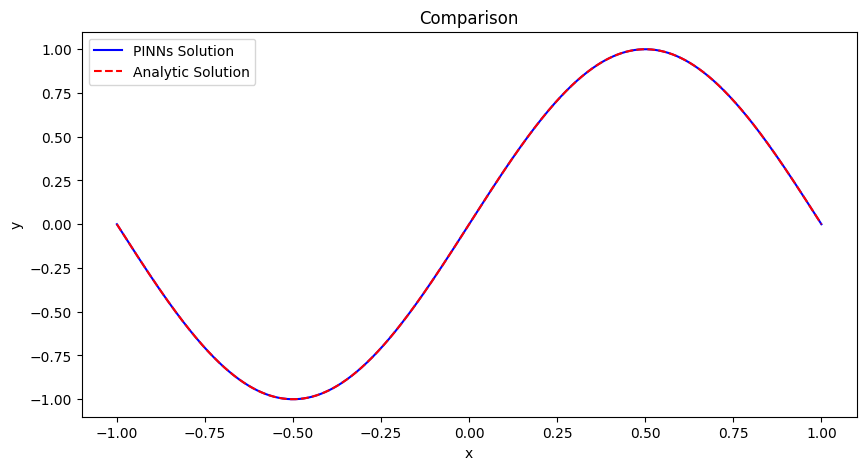

In [24]:
# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(x_test, y_pred,'b-', label='PINNs Solution')
plt.plot(x_test, y_analytic,'r--', label='Analytic Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("Comparison")
plt.show()